In [1]:
%run geminiGeneratedHelper.ipynb 

Generated A-scan. Target peak found at range bin: 4


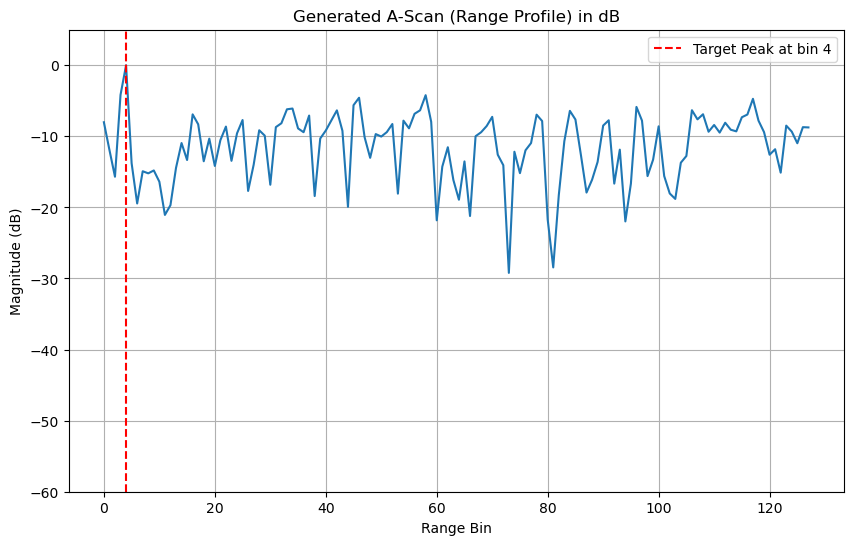

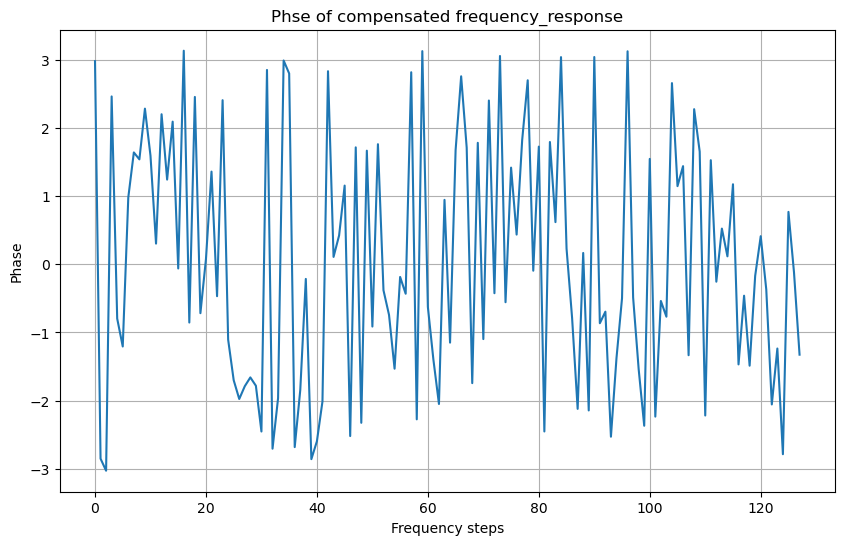

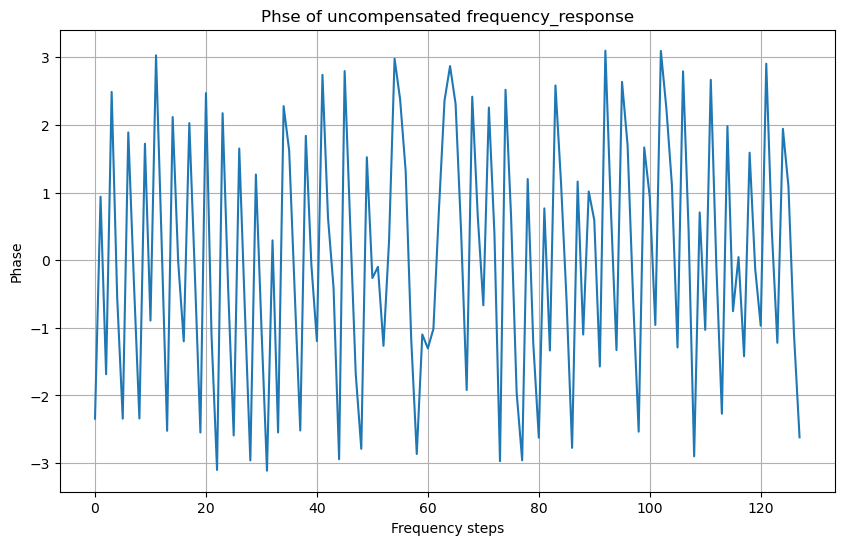

signal_power:  5.915743229407411e-05
average_noise_power:  6.101762416887313e-06


np.float64(9.865539505738099)

In [5]:
SAMPLING_RATE = 5e6    # 5 MHz
BASEBAND_FREQ = 100e3   # 100 kHz
burst_len = 1024+128
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/loop_back_cw/'
prefix = ''
i=0
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
cut_off = 2.4e6
transition_width = 1e6
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_cw(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    baseband_freq_hz=BASEBAND_FREQ,
    sampling_rate_hz=SAMPLING_RATE
)

plotResults(ascan_profile, calibrated_channel_response, echo_response)

calculate_snr(ascan_profile)

In [6]:
ascan_profile

array([ 3.07079425e-02+2.34167847e-02j, -4.68861177e-02-7.04967815e-02j,
        1.04720350e-01+9.76570072e-02j, -1.65931106e+00-1.83390227e+00j,
        2.87321978e+00+3.14792242e+00j, -7.64197988e-01-1.19507436e+00j,
       -1.84383729e-01+1.51522508e-01j,  7.70462962e-02-1.79719863e-02j,
       -3.86580096e-02-5.61058789e-02j,  5.70188790e-03+7.66221088e-02j,
        3.69858657e-02-1.48233933e-02j, -8.01098039e-02+5.26305370e-02j,
        8.29881773e-02-8.29765414e-02j, -1.15399886e-02+5.86066535e-02j,
        3.11735464e-02+3.70492772e-02j, -2.31185017e-02-1.40608050e-01j,
        4.91834807e-03+1.27363598e-01j,  4.81762227e-03-1.59226633e-02j,
        1.12431333e-02-6.47467414e-03j, -3.99058161e-04+1.02075263e-02j,
        1.46948732e-02-1.48622043e-02j, -7.25635824e-03+1.34747481e-02j,
        5.06421243e-03+2.13702465e-02j,  1.68636187e-02-5.65648349e-03j,
        5.48718923e-03+6.49733952e-03j,  3.88325234e-03-5.20005305e-03j,
       -6.34600690e-03+8.75543653e-04j,  1.48989922

signal_power:  7.855047496844124e-05
average_noise_power:  7.878043987813151e-06
Baseline Single-Pulse SNR: 9.99 dB
signal_power:  0.0001065397760621941
average_noise_power:  4.750262721073972e-06
  - Stacks (N=   2): Stacked SNR= 13.51 dB, Gain=  3.52 dB
signal_power:  0.00010854499109972364
average_noise_power:  3.4654114484133367e-06
  - Stacks (N=   4): Stacked SNR= 14.96 dB, Gain=  4.97 dB
signal_power:  0.00010014150696268631
average_noise_power:  2.4599092001120805e-06
  - Stacks (N=   8): Stacked SNR= 16.10 dB, Gain=  6.11 dB
signal_power:  0.00011362680340416908
average_noise_power:  1.8529410096429061e-06
  - Stacks (N=  16): Stacked SNR= 17.88 dB, Gain=  7.89 dB
signal_power:  0.00011493538173523375
average_noise_power:  1.5435790643589749e-06
  - Stacks (N=  32): Stacked SNR= 18.72 dB, Gain=  8.73 dB
signal_power:  0.0001217711241101386
average_noise_power:  1.433507692582549e-06
  - Stacks (N=  64): Stacked SNR= 19.29 dB, Gain=  9.30 dB
signal_power:  0.0001162242906262341

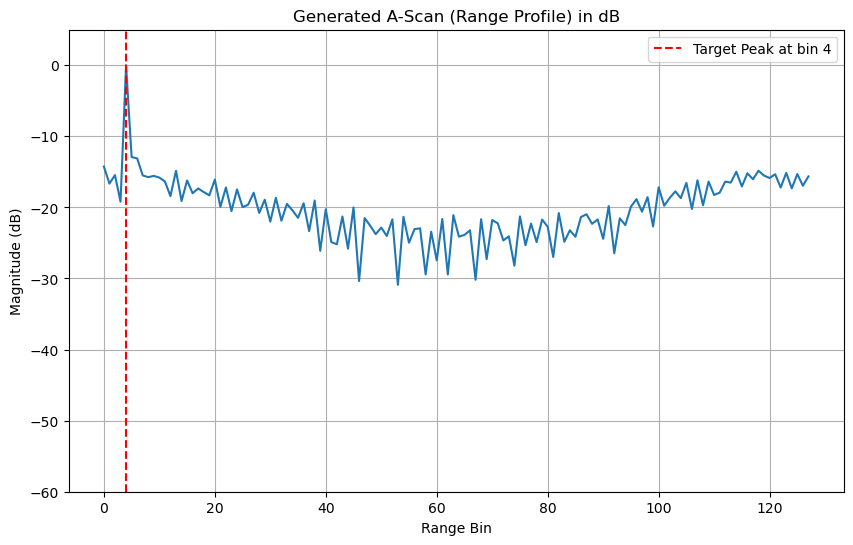

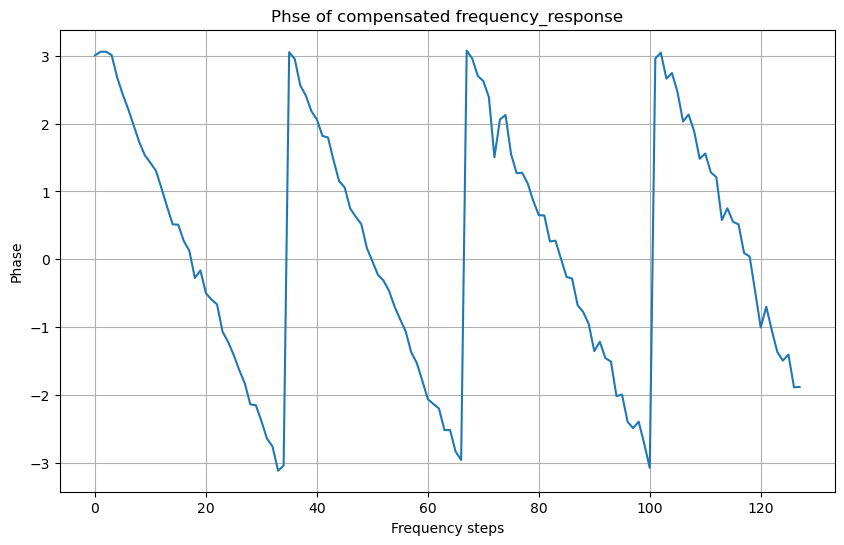

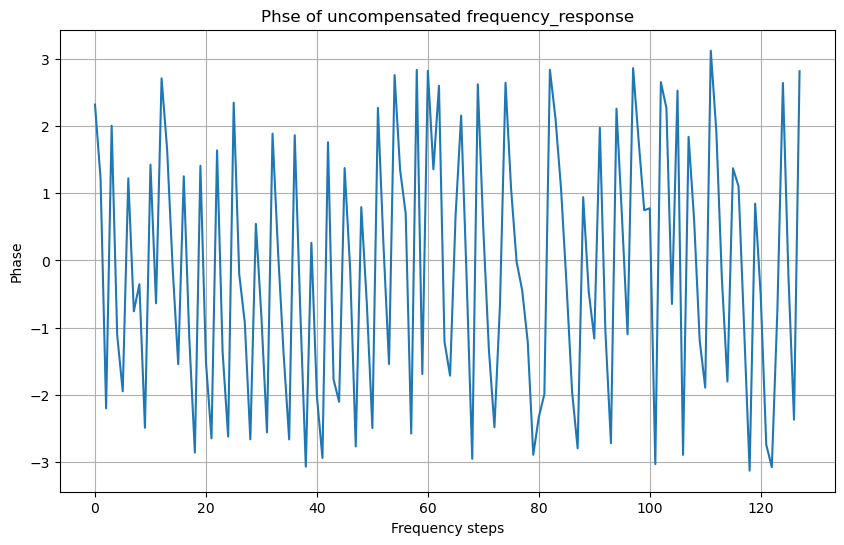

In [7]:
SAMPLING_RATE = 5e6    # 5 MHz
BASEBAND_FREQ = 100e3   # 100 kHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/loop_back_cw_2/'
prefix = ''

channel_responses = []
for i in range(512):
    fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
    fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
    rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)
    
    # --- Generate the A-scan using the function ---
    ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_cw(
        echo_signals=rx_samples,
        reference_signals=ref_samples,
        num_steps=num_steps,
        step_length=burst_len,
        baseband_freq_hz=BASEBAND_FREQ,
        sampling_rate_hz=SAMPLING_RATE
    )
    channel_responses.append(calibrated_channel_response)
channel_responses = np.array(channel_responses)

actual_stack_sizes, processing_gains_db, a_scan_stacked, stacked_freq_response = calculate_processing_gain(channel_responses)

plotResults(a_scan_stacked, stacked_freq_response, echo_response)